#Project-4
#Algorthmic Bias
# By Divya Sai sukanya

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [99]:
hennepin = pd.read_csv("/content/mortgage_covenant_data.csv")
hennepin.head()


,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


In [100]:
numeric_cols = [
    "loan_amount",
    "property_value",
    "income",
    "interest_rate"
]

for col in numeric_cols:
    hennepin[col] = pd.to_numeric(hennepin[col], errors="coerce")


Databias Analysis for Hennepin

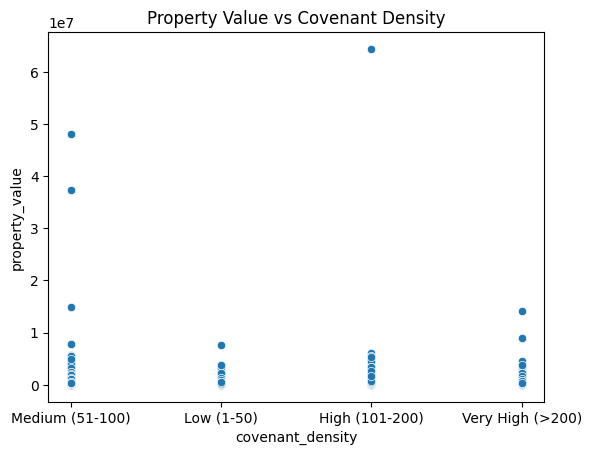

In [101]:
# Property Value vs Covenant Density
sns.scatterplot(x="covenant_density", y="property_value", data=hennepin)
plt.title("Property Value vs Covenant Density")
plt.show()


This scatter plot shows the relationship between covenant_density and property_value.Most property values fall below 10,000,000, but a few outliers reach around 65,000,000, tells that historical housing discrimination may still influence modern housing prices.

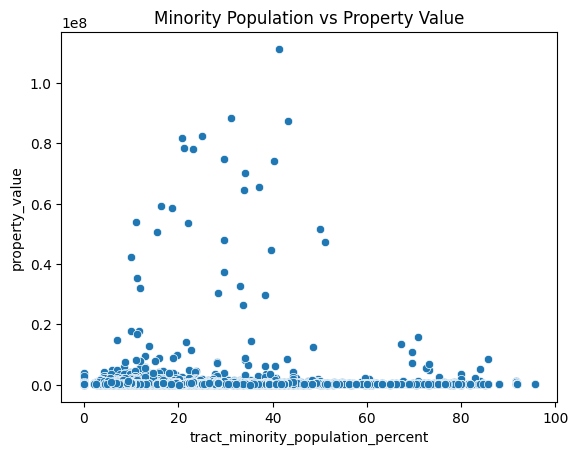

In [102]:
# Minority Population vs Property Value
sns.scatterplot(
    x="tract_minority_population_percent",
    y="property_value",
    data=hennepin
)

plt.title("Minority Population vs Property Value")
plt.show()


This scatter plot shows the relationship between minority_population and property_value.Most property values remain below 20,000,000 although some outliers reach above 110,000,000, shows that property values vary widely across neighborhoods with different minority population percentages.

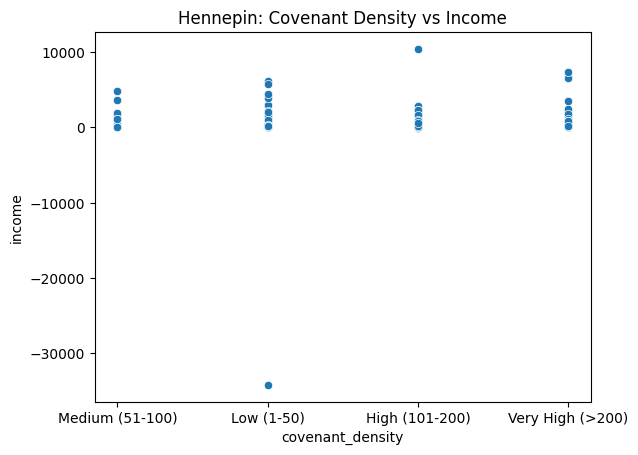

In [103]:
# Covenant Density vs Income
sns.scatterplot(x="covenant_density", y="income", data=hennepin)
plt.title("Hennepin: Covenant Density vs Income")
plt.show()


This scatter plot shows the relationship between covenant_density and income levels.Most income values range between 0 and 6,000, with a few outliers above 10,000 and one negative value around -35,000, suggesting income varies across covenant density groups but without a strong visible trend.

Algorthmic bias for hennepin

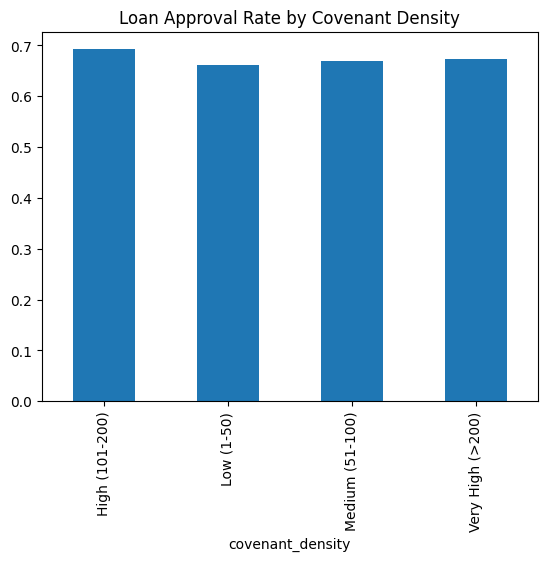

In [104]:
# Loan Approval Rate
hennepin.groupby("covenant_density")["was_approved"].mean().plot(kind="bar")
plt.title("Loan Approval Rate by Covenant Density")
plt.show()


This bar chart shows the relationship between covenant_density and loan approval rates. The approval rates are relatively similar across groups around in the percentage of 60%-69% it shows that only small differences in approval outcomes across covenant density categories.

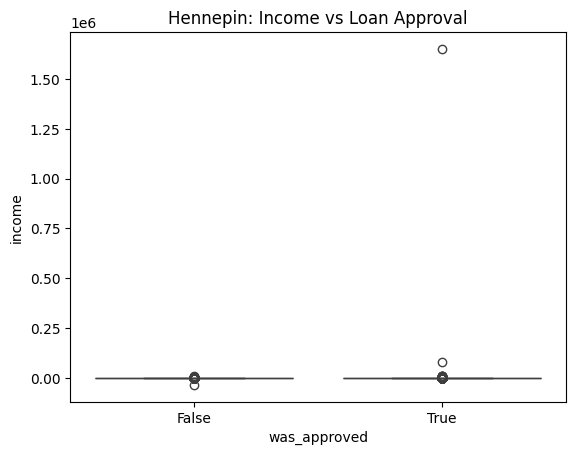

In [105]:
# Income vs Loan Approval
sns.boxplot(x="was_approved", y="income", data=hennepin)
plt.title("Hennepin: Income vs Loan Approval")
plt.show()

This boxplot shows the relationship between borrower income and loan approval status. Most incomes clusters below 100,000, while approved loans include several higher-income outliers reaching around 1,600,000, shows that higher income applicants may have a greater likelihood of loan approval.

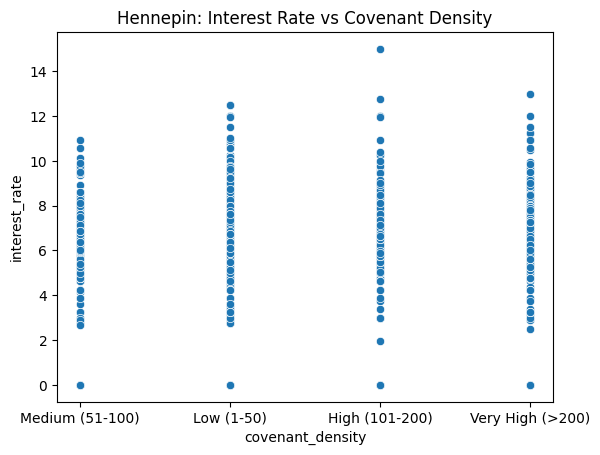

In [106]:
# Interest Rate vs Covenant Density
sns.scatterplot(x="covenant_density", y="interest_rate", data=hennepin)
plt.title("Hennepin: Interest Rate vs Covenant Density")
plt.show()

This scatter plot shows the relationship between covenant_density and interest_rate. Most interest rates fall between 3% and 11% across all covenant density categories,but one with 15% indicating that interest rates are distributed similarly across areas with different covenant densities.

Correlation heat map for hennepin

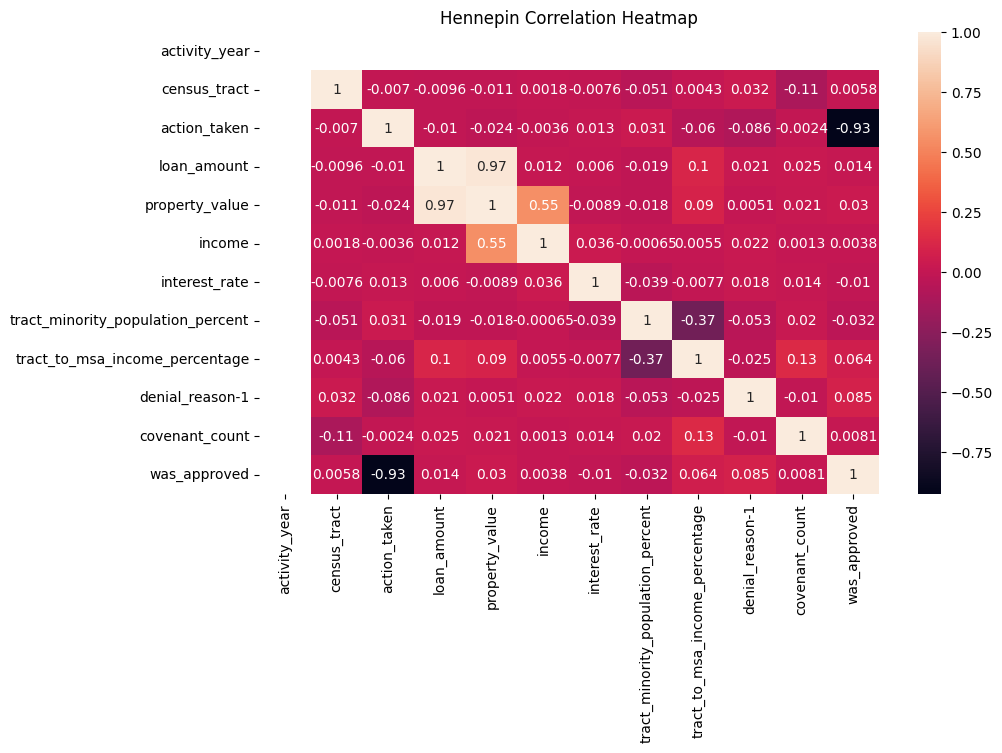

In [107]:
plt.figure(figsize=(10,6))
sns.heatmap(hennepin.corr(numeric_only=True), annot=True)
plt.title("Hennepin Correlation Heatmap")
plt.show()


This correlation heatmap shows the relationships between numerical variables in the Hennepin dataset, helping identify which factors are related to mortgage approval and housing characteristics. The strongest positive relationship is between loan_amount and property_value (0.97), while income and property_value show a moderate correlation (0.55), indicating that larger loans are strongly associated with higher property values and income also plays a role in housing value

Analysis on Ramsey Dataset

In [108]:
import pandas as pd
ramsey_cov = pd.read_csv("covenants-mn-ramsey-county.csv")
ramsey_mortgage = pd.read_csv("county_27123.csv")
# Prepare ramsey_cov_slim and calculate covenant_density
ramsey_cov_slim = ramsey_cov[[
    'db_id',
    'deed_year',
    'city',
    'zip_code',
    'cov_text'
]].copy()
ramsey_cov_slim['has_covenant'] = 1
covenant_density = ramsey_cov_slim.groupby('zip_code').size().reset_index()
covenant_density.columns = ['zip_code', 'covenant_density']
covenant_density['zip_code'] = covenant_density['zip_code'].astype(str)



In [109]:
# Prepare ramsey_mortgage_slim
ramsey_mortgage_slim = ramsey_mortgage[[
    'census_tract',
    'derived_race',
    'derived_ethnicity',
    'derived_sex',
    'loan_amount',
    'interest_rate',
    'loan_to_value_ratio',
    'action_taken'
]].copy()
ramsey_mortgage_slim['approved'] = (
    ramsey_mortgage_slim['action_taken'] == 1
).astype(int)
ramsey_mortgage_slim['zip_code'] = ramsey_mortgage_slim['census_tract'].astype(str).str[:5]
# Merge and fill NaNs to create ramsey_analysis
ramsey_analysis = pd.merge(
    ramsey_mortgage_slim,
    covenant_density,
    on='zip_code',
    how='left'
)
ramsey_analysis['covenant_density'] = ramsey_analysis['covenant_density'].fillna(0)
print("ramsey_analysis DataFrame created successfully.")
display(ramsey_analysis.head())

ramsey_analysis DataFrame created successfully.


,census_tract,derived_race,derived_ethnicity,derived_sex,loan_amount,interest_rate,loan_to_value_ratio,action_taken,approved,zip_code,covenant_density
0,2.712304e+10,Joint,Not Hispanic or Latino,Joint,665000.0,7.200,85.00000,1,1,27123,0.0
1,2.712304e+10,Asian,Not Hispanic or Latino,Joint,635000.0,NaN,NaN,4,0,27123,0.0
2,2.712304e+10,White,Not Hispanic or Latino,Male,155000.0,6.875,26.08700,1,1,27123,0.0
3,2.712304e+10,White,Not Hispanic or Latino,Joint,205000.0,7.125,95.00000,1,1,27123,0.0
4,2.712303e+10,White,Not Hispanic or Latino,Male,255000.0,NaN,NaN,4,0,27123,0.0


In [110]:
numeric_cols = [
    "loan_amount",
    "property_value",
    "income",
    "interest_rate"
]

for col in numeric_cols:
    ramsey_mortgage[col] = pd.to_numeric(ramsey_mortgage[col], errors="coerce")


In [111]:
ramsey_mortgage["was_approved"] = ramsey_mortgage["action_taken"] == 1


Databias analysis for ramsey

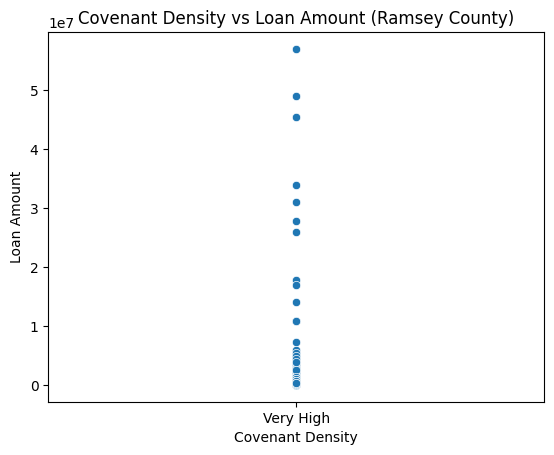

In [112]:
# Covenant Density vs Loan Amount
sns.scatterplot(
    x="covenant_density",
    y="loan_amount",
    data=ramsey
)

plt.title("Covenant Density vs Loan Amount (Ramsey County)")
plt.xlabel("Covenant Density")
plt.ylabel("Loan Amount")

plt.show()

This scatter plot shows that the most loan amounts are below 5,000,000, while a few outliers reach around 55,000,000, indicating that areas with very high covenant density still show large variation in loan sizes.

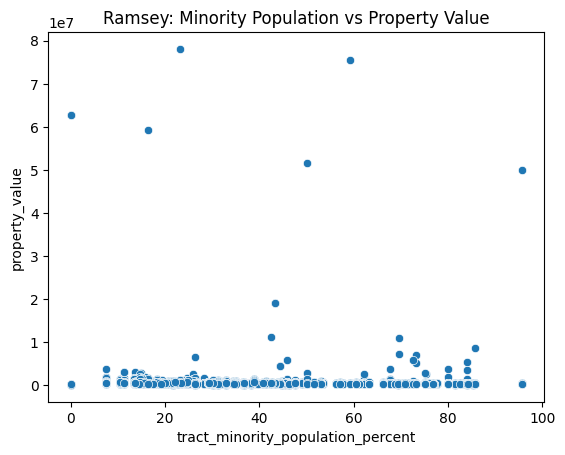

In [113]:
# Property Value vs Covenant Density
sns.scatterplot(
    x="tract_minority_population_percent",
    y="property_value",
    data=ramsey
)

plt.title("Ramsey: Minority Population vs Property Value")
plt.show()


This scatter plot shows that the most property values remain below 5,000,000, although several outliers reach between 60,000,000 and 80,000,000, shows that property values vary widely across neighborhoods with different minority population percentages.

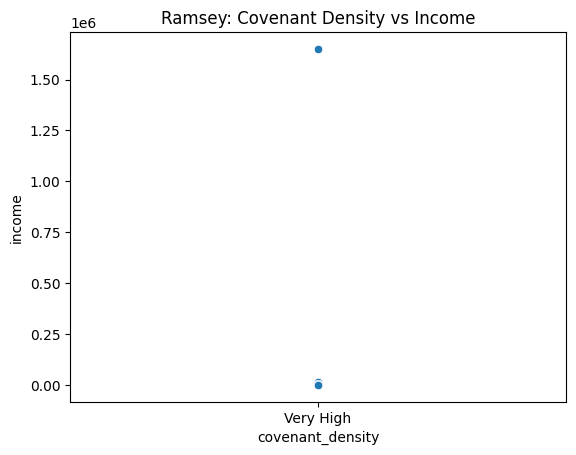

In [114]:
# Covenant Density vs Income
sns.scatterplot(x="covenant_density", y="income", data=ramsey)
plt.title("Ramsey: Covenant Density vs Income")
plt.show()


 This scatter plot shows that the most income values appear close to 0–100,000, while one outlier reaches approximately 1,600,000, indicating that income levels vary but are generally concentrated at lower values within areas of very high covenant density.

Algorithmic bias for Ramsey

/tmp/ipykernel_243/1389456915.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ramsey.groupby("covenant_density")["was_approved"].mean().plot(kind="bar")


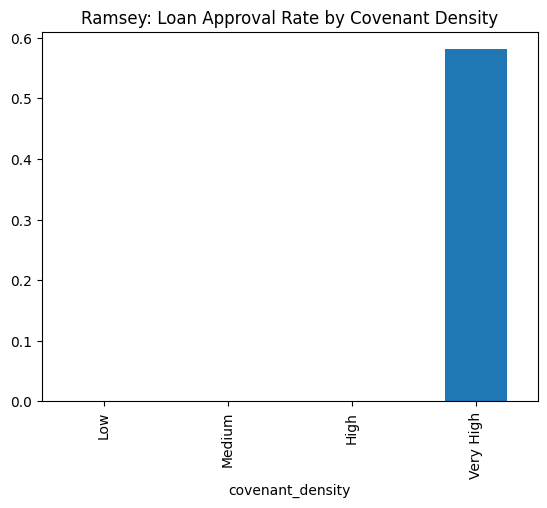

In [115]:
# Loan Approval Rate
ramsey.groupby("covenant_density")["was_approved"].mean().plot(kind="bar")
plt.title("Ramsey: Loan Approval Rate by Covenant Density")
plt.show()


This bar chart shows the relationship between covenant_density and loan approval rates in Ramsey County. i dont know what wrong but the approval rate appears only for the Very High covenant density group, with an approval rate of approximately 58%, while the other categories no visible data in this plot.

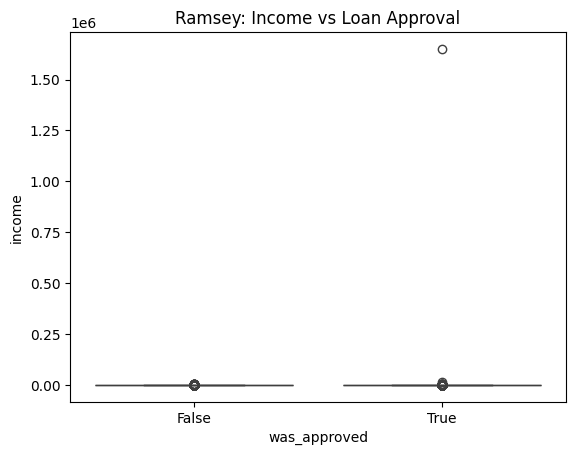

In [116]:
# Income vs Loan Approval
sns.boxplot(x="was_approved", y="income", data=ramsey)
plt.title("Ramsey: Income vs Loan Approval")
plt.show()


This boxplot shows the relationship between borrower income and loan approval status in Ramsey County. Most income values appear below 100,000, while one approved loan shows a very high outlier around 1,650,000, shows that higher-income applicants may have a greater chance of loan approval.

Heatmap for ramsey

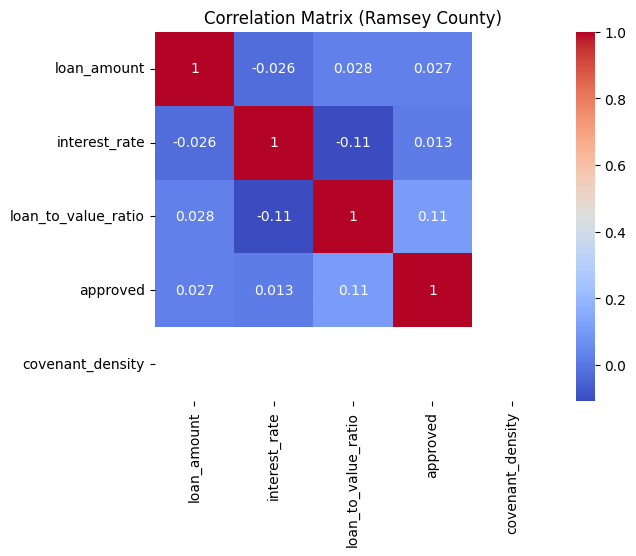

In [117]:
ramsey_analysis['loan_amount'] = pd.to_numeric(ramsey_analysis['loan_amount'], errors='coerce')
ramsey_analysis['interest_rate'] = pd.to_numeric(ramsey_analysis['interest_rate'], errors='coerce')
ramsey_analysis['loan_to_value_ratio'] = pd.to_numeric(ramsey_analysis['loan_to_value_ratio'], errors='coerce')
ramsey_analysis['approved'] = pd.to_numeric(ramsey_analysis['approved'], errors='coerce')
ramsey_analysis['covenant_density'] = pd.to_numeric(ramsey_analysis['covenant_density'], errors='coerce')

ramsey_corr = ramsey_analysis[[
    "loan_amount",
    "interest_rate",
    "loan_to_value_ratio",
    "approved",
    "covenant_density"
]].corr()

sns.heatmap(
    ramsey_corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix (Ramsey County)")
plt.show()

This correlation heatmap shows the relationships between numerical variables in the Ramsey County dataset factors may influence mortgage approval. The strongest relationship is between loan_to_value_ratio and approved by 0.11, while other variables such as loan_amount and interest_rate is 0.026 and loan_amount and approved 0.027 shows very weak correlations, indicating that most variables in this dataset have only a small influence on loan approval outcomes.

Comparison for hennepin and Ramsey

In [118]:
hennepin_df = pd.read_csv("mortgage_covenant_data.csv")
ramsey_df =pd.read_csv("/content/covenants-mn-ramsey-county.csv")

In [119]:
hennepin_approval = hennepin_df["was_approved"].mean()
ramsey_approval = ramsey["was_approved"].mean()

print("Hennepin Approval Rate:", hennepin_approval)
print("Ramsey Approval Rate:", ramsey_approval)

Hennepin Approval Rate: 0.6646619968097017
Ramsey Approval Rate: 0.5806518436680017


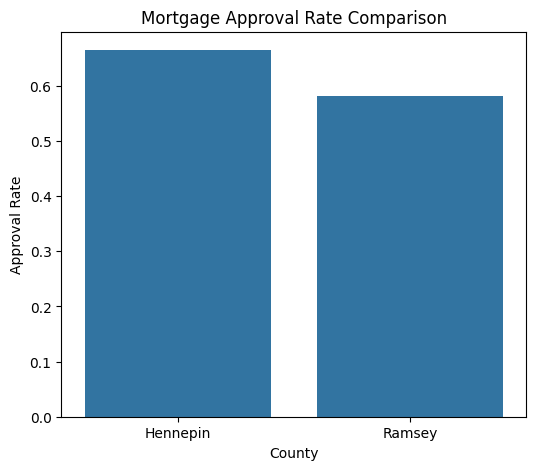

In [120]:
hennepin_approval = hennepin_df["was_approved"].mean()
ramsey_approval = ramsey["was_approved"].mean()

approval_data = {
    "County": ["Hennepin", "Ramsey"],
    "Approval Rate": [hennepin_approval, ramsey_approval]
}

approval_df = pd.DataFrame(approval_data)
plt.figure(figsize=(6,5))
sns.barplot(data=approval_df, x="County", y="Approval Rate")

plt.title("Mortgage Approval Rate Comparison")
plt.ylabel("Approval Rate")
plt.xlabel("County")
plt.show()

This bar chart compares the overall mortgage approval rates between Hennepin and Ramsey counties. Hennepin County has an approval rate of approximately 0.66 (66.5%), while Ramsey County has a lower approval rate of about 0.58 (58.1%), indicating that mortgage applications in Hennepin County are approved more often than in Ramsey County.

In [121]:
print("Average Income Hennepin:", hennepin_df["income"].mean())
print("Average Income Ramsey:", ramsey["income"].mean())

Average Income Hennepin: 148.96602040816327
Average Income Ramsey: 244.16980126399147


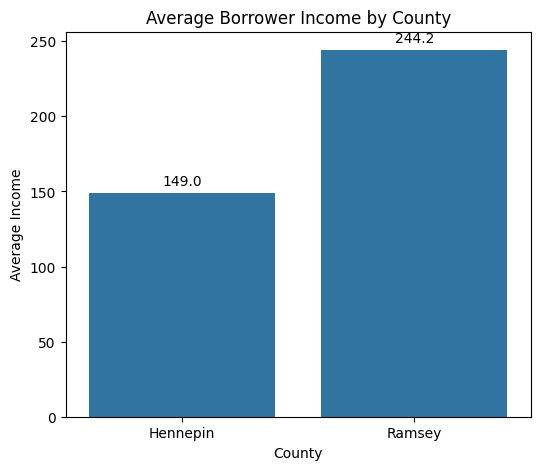

In [122]:
income_data = {
    "County": ["Hennepin", "Ramsey"],
    "Average Income": [hennepin_df["income"].mean(), ramsey["income"].mean()]
}
income_df = pd.DataFrame(income_data)

plt.figure(figsize=(6,5))
ax = sns.barplot(data=income_df, x="County", y="Average Income")

for i, v in enumerate(income_df["Average Income"]):
    ax.text(i, v + 5, f"{v:.1f}", ha="center")

plt.title("Average Borrower Income by County")
plt.xlabel("County")
plt.ylabel("Average Income")
plt.show()

This bar chart compares the average borrower income between Hennepin and Ramsey counties. Hennepin County has an average borrower income of approximately 149.0, while Ramsey County shows a higher average income of about 244.2, indicating that borrowers in Ramsey County generally report higher income levels than those in Hennepin County.

In [123]:
print("Average Property Value Hennepin:", hennepin_df["property_value"].mean())
print("Average Property Value Ramsey:", ramsey["property_value"].mean())

Average Property Value Hennepin: 398772.62219879986
Average Property Value Ramsey: 403635.35439795046


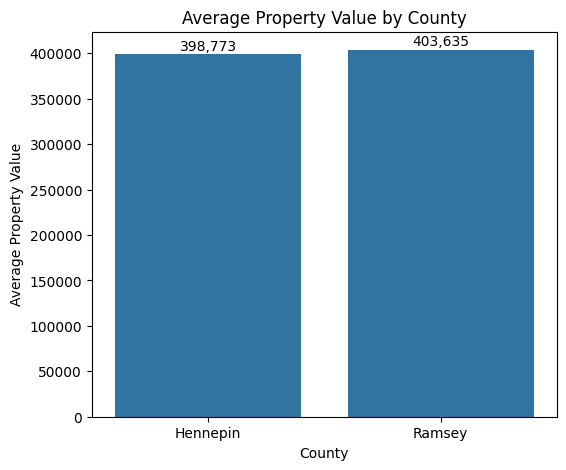

In [124]:
plt.figure(figsize=(6,5))
ax = sns.barplot(data=property_df, x="County", y="Average Property Value")

for i, v in enumerate(property_df["Average Property Value"]):
    ax.text(i, v + 5000, f"{v:,.0f}", ha="center")

plt.title("Average Property Value by County")
plt.xlabel("County")
plt.ylabel("Average Property Value")

plt.show()

This bar chart compares the average property values between Hennepin and Ramsey counties. Hennepin County has an average property value of approximately 398,773, while Ramsey County shows a slightly higher average of about 403,635, indicating that property values are relatively similar but marginally higher in Ramsey County.

In [125]:
comparison = pd.DataFrame({

    "Metric":[
        "Average Property Value",
        "Average Income",
        "Loan Approval Rate",
        "Average Interest Rate"
    ],

    "Hennepin":[
        hennepin["property_value"].mean(),
        hennepin["income"].mean(),
        hennepin["was_approved"].mean(),
        hennepin["interest_rate"].mean()
    ],

    "Ramsey":[
        ramsey["property_value"].mean(),
        ramsey["income"].mean(),
        ramsey["was_approved"].mean(),
        ramsey["interest_rate"].mean()
    ]

})

comparison


,Metric,Hennepin,Ramsey
0,Average Property Value,398772.622199,403635.354398
1,Average Income,148.966020,244.169801
2,Loan Approval Rate,0.664662,0.580652
3,Average Interest Rate,6.575084,6.879266


<Figure size 600x1000 with 0 Axes>

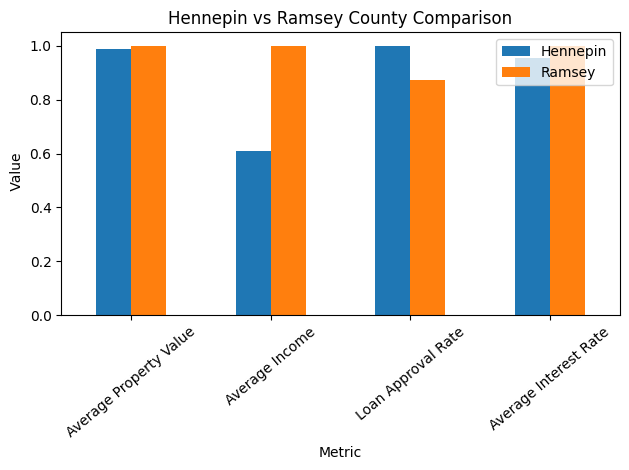

In [126]:
# Create a copy
comparison_norm = comparison.copy()

# Normalize each row so metrics become comparable
comparison_norm[["Hennepin","Ramsey"]] = comparison_norm[["Hennepin","Ramsey"]].div(
    comparison_norm[["Hennepin","Ramsey"]].max(axis=1), axis=0
)

# Plot
comparison_plot = comparison_norm.set_index("Metric")

plt.figure(figsize=(6,10))
comparison_plot.plot(kind="bar")

plt.title("Hennepin vs Ramsey County Comparison")
plt.xlabel("Metric")
plt.ylabel(" Value")
plt.xticks(rotation=40)

plt.tight_layout()
plt.show()

The chart shows that Ramsey County has a higher average borrower income about 244 than Hennepin County about 149, but Hennepin still has a higher loan approval rate about 66.5% compared to Ramsey about 58.1%. This suggests that factors other than income may influence mortgage approval outcomes.

This chart indicates potential algorithmic bias, where lending decisions could be influenced by other variables such as property values, neighborhood characteristics, or historical housing patterns rather than borrower income alone. It may also reflect data bias, since historical housing discrimination and neighborhood economic differences may still be embedded in the data used by modern lending systems.